/var/folders/pl/vxvp849x7cq56cpszbltdh9r0000gn/T/ipykernel_83722/552827224.py:12: DtypeWarning: Columns (12,14,15,22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/aavsodata_6936152b9f414.txt", comment='#')


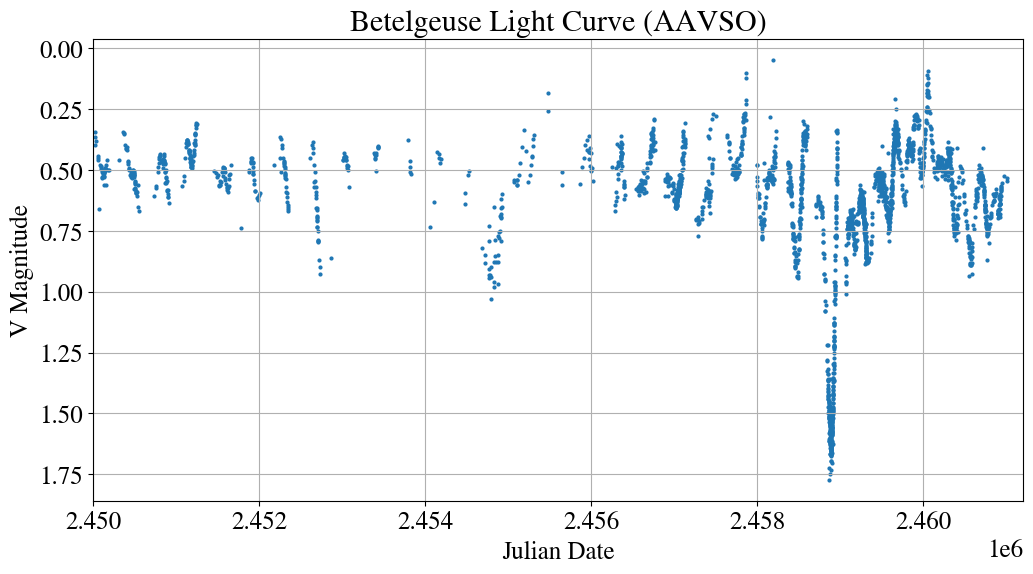

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from matplotlib import rcParams
rcParams['figure.figsize']=(6,6)
rcParams['font.family']='STIXGeneral'
rcParams['font.size']=18
rcParams['mathtext.fontset']='stix'
rcParams['legend.numpoints']=1 

df = pd.read_csv("../data/aavsodata_6936152b9f414.txt", comment='#')
df = df[['JD', 'Magnitude', 'Band']]
df = df.dropna(subset=['Magnitude'])
df = df[df['Band'] == 'V']
df['Magnitude'] = pd.to_numeric(df['Magnitude'], errors='coerce')
df = df.dropna(subset=['Magnitude'])

JD = df['JD']
mag = df['Magnitude']
JD = np.array(JD)
mag = np.array(mag)

plt.figure(figsize=(12,6))
plt.scatter(JD, mag, s=4, color = 'tab:blue')
# plt.plot(JD, mag, color='red')
plt.gca().invert_yaxis()
plt.xlabel("Julian Date")
plt.xlim(2.45e6,2.4612e6)
plt.ylabel("V Magnitude")
plt.title("Betelgeuse Light Curve (AAVSO)")
plt.grid()
plt.show()

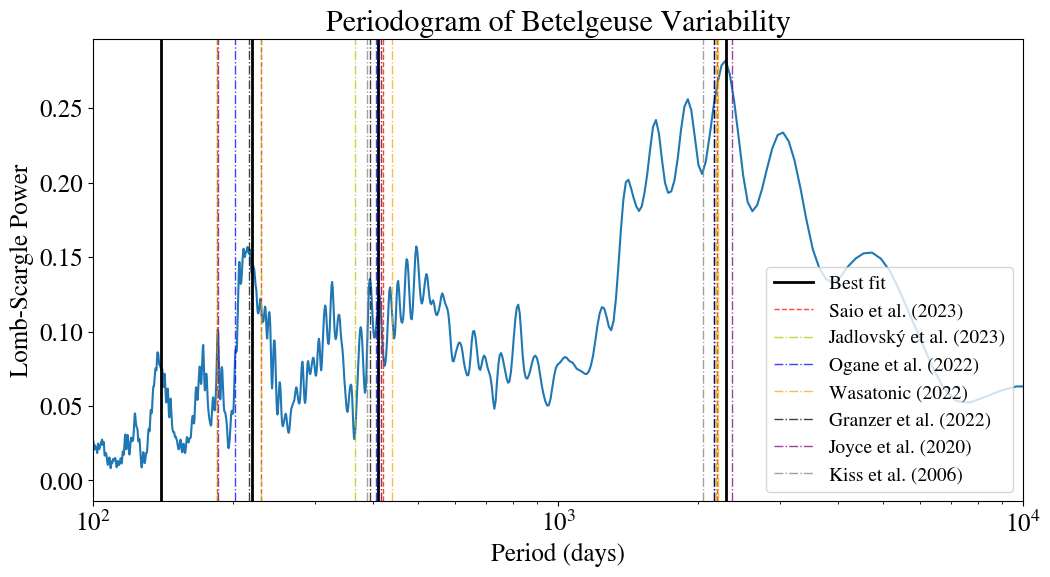

In [6]:
from astropy.timeseries import LombScargle

t = JD
y = mag
y = y - np.mean(y)

freq, power = LombScargle(t, y).autopower()

period = 1/freq

plt.figure(figsize=(12,6))
plt.plot(period, power)

best_period = period[np.argmax(power)]

plt.axvline(x=best_period, color='k', linestyle='-', linewidth=2, alpha=1, label='Best fit')
plt.axvline(x=410, color='k', linestyle='-', linewidth=2, alpha=1)
plt.axvline(x=220, color='k', linestyle='-', linewidth=2, alpha=1)
plt.axvline(x=140, color='k', linestyle='-', linewidth=2, alpha=1)

plt.axvline(x=185, color='r', linestyle='--', linewidth=1, alpha=0.75, label='Saio et al. (2023)')
plt.axvline(x=230, color='r', linestyle='--', linewidth=1, alpha=0.75)
plt.axvline(x=420, color='r', linestyle='--', linewidth=1, alpha=0.75)
plt.axvline(x=2200, color='r', linestyle='--', linewidth=1, alpha=0.75)

plt.axvline(x=185, color='y', linestyle='-.', linewidth=1, alpha=0.75, label='Jadlovský et al. (2023)')
plt.axvline(x=230, color='y', linestyle='-.', linewidth=1, alpha=0.75)
plt.axvline(x=365, color='y', linestyle='-.', linewidth=1, alpha=0.75)
plt.axvline(x=417, color='y', linestyle='-.', linewidth=1, alpha=0.75)
plt.axvline(x=2190, color='y', linestyle='-.', linewidth=1, alpha=0.75)

plt.axvline(x=405, color='b', linestyle='-.', linewidth=1, alpha=0.75, label='Ogane et al. (2022)')
plt.axvline(x=2160, color='b', linestyle='-.', linewidth=1, alpha=0.75)
plt.axvline(x=202, color='b', linestyle='-.', linewidth=1, alpha=0.75)

plt.axvline(x=439, color='orange', linestyle='-.', linewidth=1, alpha=0.75, label='Wasatonic (2022)')
plt.axvline(x=2209, color='orange', linestyle='-.', linewidth=1, alpha=0.75)

plt.axvline(x=394, color='k', linestyle='-.', linewidth=1, alpha=0.75, label='Granzer et al. (2022)')
plt.axvline(x=2169, color='k', linestyle='-.', linewidth=1, alpha=0.75)
plt.axvline(x=216, color='k', linestyle='-.', linewidth=1, alpha=0.75)

plt.axvline(x=416, color='purple', linestyle='-.', linewidth=1, alpha=0.75, label='Joyce et al. (2020)')
plt.axvline(x=2365, color='purple', linestyle='-.', linewidth=1, alpha=0.75)
plt.axvline(x=185.5, color='purple', linestyle='-.', linewidth=1, alpha=0.75)

plt.axvline(x=388, color='grey', linestyle='-.', linewidth=1, alpha=0.75, label='Kiss et al. (2006)')
plt.axvline(x=2050, color='grey', linestyle='-.', linewidth=1, alpha=0.75)

plt.xscale('log')
plt.xlabel("Period (days)")
plt.xlim(1e2,1e4)
plt.ylabel("Lomb-Scargle Power")
plt.legend(fontsize=14)
plt.title("Periodogram of Betelgeuse Variability")
plt.show()

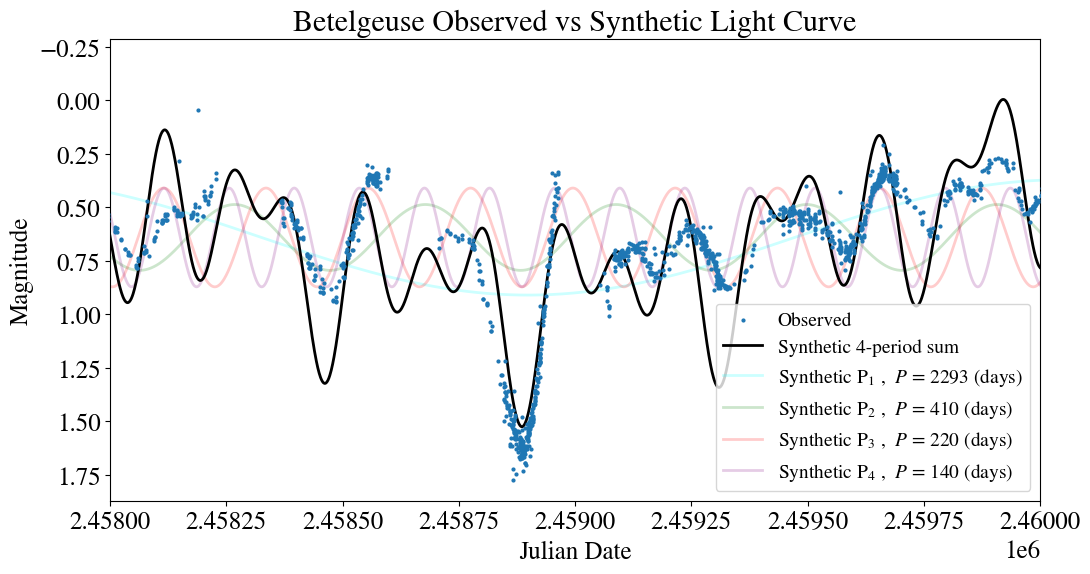

In [ ]:
P1= 2293
P2= 410
P3= 220
P4= 140
A1= 0.35/1.3
A2= 0.2/1.3
A3= 0.3/1.3
A4= 0.3/1.3

t_min = JD.min()
t_max = JD.max()

t = np.arange(t_min, t_max, 1)

synth_P1 = A1*np.sin(2*np.pi*t/P1 + 1.8*np.pi) + np.mean(mag)
synth_P2 = A2*np.sin(2*np.pi*t/P2 + 3.9*np.pi/2) + np.mean(mag)
synth_P3 = A3*np.sin(2*np.pi*t/P3 + 2*np.pi/2) + np.mean(mag)
synth_P4 = A4*np.sin(2*np.pi*t/P4 + 4.9) + np.mean(mag)
synth = A1*np.sin(2*np.pi*t/P1  + 1.8*np.pi) + A2*np.sin(2*np.pi*t/P2 + 3.9*np.pi/2) + A3*np.sin(2*np.pi*t/P3 + 2*np.pi/2) + A4*np.sin(2*np.pi*t/P4 +4.9) + np.mean(mag)

plt.figure(figsize=(12,6))
plt.scatter(JD, mag, s=4, label='Observed', zorder=5)
plt.plot(t, synth, color='k', linewidth=2, label='Synthetic 4-period sum')
plt.plot(t, synth_P1, color='aqua', linewidth=2, label=f'Synthetic P$_1$ ,  $P$ = {P1} (days)', zorder=-5, alpha=0.2)
plt.plot(t, synth_P2, color='green', linewidth=2, label=f'Synthetic P$_2$ ,  $P$ = {P2} (days)', zorder=-5, alpha=0.2)
plt.plot(t, synth_P3, color='red', linewidth=2, label=f'Synthetic P$_3$ ,  $P$ = {P3} (days)', zorder=-5, alpha=0.2)
plt.plot(t, synth_P4, color='purple', linewidth=2, label=f'Synthetic P$_4$ ,  $P$ = {P4} (days)', zorder=-5, alpha=0.2)
plt.gca().invert_yaxis()
plt.xlabel("Julian Date")
plt.ylabel("Magnitude")
plt.xlim(2.458e6,2.46e6)
plt.title("Betelgeuse Observed vs Synthetic Light Curve")
plt.legend(fontsize=14, loc='lower right')
plt.show()